# NB03 — H3 family composition + phylum-stratified H1/H2

Runs locally against NB01 cached TSVs.

- **H3**: TA family composition (Shannon entropy of family fractions) differs by lifestyle.
- **Phylum control**: rerun H1 (paired non-core Wilcoxon) and H2 (Mann-Whitney per Mb) within each of the 10 lifestyle_cog phyla. Require ≥6/10 phyla to preserve direction of whole-cohort effect.
- **Family-level H3 test**: per-family per-Mb rate host vs free, BH-FDR corrected.


In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path('../data')
FIG = Path('../figures')
FIG.mkdir(exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


## 1. Load NB01 outputs and lifestyle labels


In [2]:
ta_species = pd.read_csv(DATA / 'ta_per_species.tsv', sep='\t')
family_comp = pd.read_csv(DATA / 'ta_family_composition_per_species.tsv', sep='\t')
baseline = pd.read_csv(DATA / 'species_gene_cluster_baseline.tsv', sep='\t')
lifestyle = pd.read_csv('../../lifestyle_cog/data/species_lifestyle_classification.csv')

# Cohort with all pieces (TA + baseline + lifestyle + genome_size)
merged = (
    ta_species
    .merge(family_comp, on='gtdb_species_clade_id', how='left')
    .merge(baseline, on='gtdb_species_clade_id', how='left')
    .merge(lifestyle[['gtdb_species_clade_id', 'species_lifestyle', 'phylum']],
           on='gtdb_species_clade_id', how='inner')
    .dropna(subset=['median_size_mb'])
)
print(f"Cohort: {len(merged):,}")
print(merged['species_lifestyle'].value_counts())
print()
print(merged['phylum'].value_counts())


Cohort: 2,403
species_lifestyle
host_associated    1660
free_living         743
Name: count, dtype: int64

phylum
p__Pseudomonadota        811
p__Bacillota_A           361
p__Bacteroidota          300
p__Bacillota             298
p__Actinomycetota        264
p__Campylobacterota       53
p__Cyanobacteriota        43
p__Bacillota_C            30
p__Spirochaetota          29
p__Verrucomicrobiota      25
p__Patescibacteria        24
p__Thermoproteota         17
p__Chloroflexota          17
p__Desulfobacterota       15
p__Halobacteriota         13
p__Thermoplasmatota       13
p__Fusobacteriota         10
p__Methanobacteriota      10
p__Marinisomatota          9
p__Acidobacteriota         7
p__Planctomycetota         7
p__Chlamydiota             4
p__Myxococcota             4
p__Gemmatimonadota         4
p__Nitrospirota            4
p__Thermotogota            4
p__Synergistota            3
p__SAR324                  2
p__Armatimonadota          2
p__Desulfobacterota_F      2
p__Nitrospinota 

## 2. H3 — Family composition asymmetry

We look at:
1. **Shannon entropy** of family-fraction distribution per species (higher → more diverse repertoire).
2. **Per-family per-Mb rate** (host vs free) with BH-FDR across families.


In [3]:
FAMILIES = [c for c in family_comp.columns if c != 'gtdb_species_clade_id']
print(f"Families in matrix: {FAMILIES}")

# Shannon entropy of family composition per species
def shannon(row):
    v = row.values.astype(float)
    v = v[v > 0]
    if v.size == 0:
        return np.nan
    p = v / v.sum()
    return float(-(p * np.log(p)).sum())

merged['family_entropy'] = merged[FAMILIES].apply(shannon, axis=1)
print(f"Species with defined entropy: {merged['family_entropy'].notna().sum()}")


Families in matrix: ['CcdAB', 'HicAB', 'HigBA', 'HipBA', 'MazEF', 'ParDE', 'RelBE', 'VapBC', 'YoeB-YefM', 'Zeta-Epsilon']
Species with defined entropy: 2403


In [4]:
host = merged[merged['species_lifestyle'] == 'host_associated']
free = merged[merged['species_lifestyle'] == 'free_living']

# H3a: family_entropy — Mann-Whitney U
def mw(a, b, label):
    a = a.dropna()
    b = b.dropna()
    u = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1.0 - (2.0 * u.statistic) / (len(a) * len(b))
    print(f"{label:>34s}  n_host={len(a)}  n_free={len(b)}  U={u.statistic:.3g}  p={u.pvalue:.3g}  r_rb={r:+.3f}  med_host={a.median():.3g}  med_free={b.median():.3g}")
    return u.pvalue, r

_ = mw(host['family_entropy'], free['family_entropy'], 'family_entropy (host vs free)')


     family_entropy (host vs free)  n_host=1660  n_free=743  U=6.66e+05  p=0.00167  r_rb=-0.080  med_host=1.55  med_free=1.5


In [5]:
# H3b: per-family per-Mb rate, BH-FDR
family_stats = []
for fam in FAMILIES:
    a = (host[fam] / host['median_size_mb']).dropna()
    b = (free[fam] / free['median_size_mb']).dropna()
    if len(a) == 0 or len(b) == 0:
        continue
    u = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1.0 - (2.0 * u.statistic) / (len(a) * len(b))
    family_stats.append({
        'family': fam,
        'n_host': int(len(a)), 'n_free': int(len(b)),
        'median_host_per_mb': float(a.median()),
        'median_free_per_mb': float(b.median()),
        'p_raw': float(u.pvalue),
        'r_rb': float(r),
    })

fs_df = pd.DataFrame(family_stats)
fs_df['p_bh'] = multipletests(fs_df['p_raw'], method='fdr_bh')[1]
fs_df['sig_bh_005'] = fs_df['p_bh'] < 0.05
fs_df = fs_df.sort_values('r_rb')
print(fs_df.to_string(index=False))
fs_df.to_csv(DATA / 'nb03_family_stats.tsv', sep='\t', index=False)


      family  n_host  n_free  median_host_per_mb  median_free_per_mb        p_raw      r_rb         p_bh  sig_bh_005
       RelBE    1660     743            0.681271            0.000000 3.379199e-60 -0.407707 3.379199e-59        True
Zeta-Epsilon    1660     743            0.000000            0.000000 2.230382e-14 -0.178501 7.434606e-14        True
       HipBA    1660     743            0.550396            0.308935 5.545408e-08 -0.135459 1.386352e-07        True
   YoeB-YefM    1660     743            0.831108            0.647824 1.585522e-04 -0.095836 2.642536e-04        True
       MazEF    1660     743            1.118570            0.882900 6.456775e-04 -0.086724 8.070969e-04        True
       HicAB    1660     743            0.000000            0.000000 1.330824e-03 -0.073945 1.478693e-03        True
       ParDE    1660     743            1.016234            0.828152 3.671198e-02 -0.052975 3.671198e-02        True
       CcdAB    1660     743            0.000000            0.00

## 3. Phylum-stratified H1 and H2

Rerun H1 (paired non-core Wilcoxon vs baseline) and H2 (Mann-Whitney per Mb host vs free) within each phylum. Require ≥6/10 preserve direction.


In [6]:
# Prep non-core fractions and per-Mb rates for the phylum loop
merged['ta_frac_nonCore'] = ((merged['ta_accessory'] + merged['ta_singleton'])
                             / merged['ta_total'].replace(0, np.nan))
merged['baseline_frac_nonCore'] = ((merged['all_accessory'] + merged['all_singleton'])
                                   / merged['all_gene_clusters'])
merged['ta_per_mb'] = merged['ta_total'] / merged['median_size_mb']

phyla = merged['phylum'].value_counts()
phyla = phyla[phyla >= 20].index.tolist()  # need ≥ 20 species per phylum
print(f"Testable phyla: {phyla}")


Testable phyla: ['p__Pseudomonadota', 'p__Bacillota_A', 'p__Bacteroidota', 'p__Bacillota', 'p__Actinomycetota', 'p__Campylobacterota', 'p__Cyanobacteriota', 'p__Bacillota_C', 'p__Spirochaetota', 'p__Verrucomicrobiota', 'p__Patescibacteria']


In [7]:
rows = []
for ph in phyla:
    sub = merged[merged['phylum'] == ph]
    # H1 paired Wilcoxon
    ss = sub.dropna(subset=['ta_frac_nonCore', 'baseline_frac_nonCore'])
    try:
        w = stats.wilcoxon(ss['ta_frac_nonCore'], ss['baseline_frac_nonCore'],
                           alternative='greater')
        delta_med = (ss['ta_frac_nonCore'] - ss['baseline_frac_nonCore']).median()
        h1_p = float(w.pvalue)
        h1_dir = '+' if delta_med > 0 else '-'
    except ValueError:
        h1_p = np.nan
        h1_dir = '?'
        delta_med = np.nan

    # H2 Mann-Whitney by lifestyle
    h_sub = sub[sub['species_lifestyle'] == 'host_associated']['ta_per_mb'].dropna()
    f_sub = sub[sub['species_lifestyle'] == 'free_living']['ta_per_mb'].dropna()
    if len(h_sub) >= 5 and len(f_sub) >= 5:
        u2 = stats.mannwhitneyu(h_sub, f_sub, alternative='two-sided')
        r_h2 = 1.0 - (2.0 * u2.statistic) / (len(h_sub) * len(f_sub))
        h2_dir = '+' if h_sub.median() > f_sub.median() else '-'
        h2_p = float(u2.pvalue)
    else:
        r_h2 = np.nan
        h2_dir = 'n<5'
        h2_p = np.nan

    rows.append({
        'phylum': ph,
        'n_species': len(sub),
        'n_host': int((sub['species_lifestyle'] == 'host_associated').sum()),
        'n_free': int((sub['species_lifestyle'] == 'free_living').sum()),
        'H1_delta_med': float(delta_med),
        'H1_p_greater': h1_p,
        'H1_direction': h1_dir,
        'H2_r_rb': float(r_h2) if not pd.isna(r_h2) else np.nan,
        'H2_p': h2_p,
        'H2_direction': h2_dir,
        'H2_med_host': float(h_sub.median()) if len(h_sub) else np.nan,
        'H2_med_free': float(f_sub.median()) if len(f_sub) else np.nan,
    })

phylum_df = pd.DataFrame(rows)
phylum_df.to_csv(DATA / 'nb03_phylum_stratified.tsv', sep='\t', index=False)
print(phylum_df.to_string(index=False))


              phylum  n_species  n_host  n_free  H1_delta_med  H1_p_greater H1_direction   H2_r_rb         H2_p H2_direction  H2_med_host  H2_med_free
   p__Pseudomonadota        811     498     313      0.163256  5.116981e-87            + -0.038531 3.552240e-01            +     6.953495     6.582675
      p__Bacillota_A        361     356       5      0.070900  8.348527e-22            + -0.494382 5.618246e-02            +     9.098199     3.338965
     p__Bacteroidota        300     233      67      0.135436  4.995346e-36            +  0.075652 3.457561e-01            -     4.972168     4.987627
        p__Bacillota        298     248      50      0.075591  2.575137e-12            + -0.507581 1.507364e-08            +     7.137393     2.824700
   p__Actinomycetota        264     172      92      0.077267  4.602220e-10            + -0.224216 2.698603e-03            +     4.797496     3.102160
 p__Campylobacterota         53      45       8      0.163333  5.565112e-08            + -0.06

In [8]:
# Consistency counters
h1_pos = (phylum_df['H1_direction'] == '+').sum()
h2_host_higher = (phylum_df['H2_direction'] == '+').sum()
n_testable_h2 = (phylum_df['H2_direction'].isin(['+', '-'])).sum()

print(f"H1 (accessory-enriched) preserved direction in {h1_pos}/{len(phylum_df)} phyla")
print(f"H2 (host higher TA/Mb) preserved direction in {h2_host_higher}/{n_testable_h2} testable phyla")


H1 (accessory-enriched) preserved direction in 10/11 phyla
H2 (host higher TA/Mb) preserved direction in 7/9 testable phyla


## 4. Visualizations


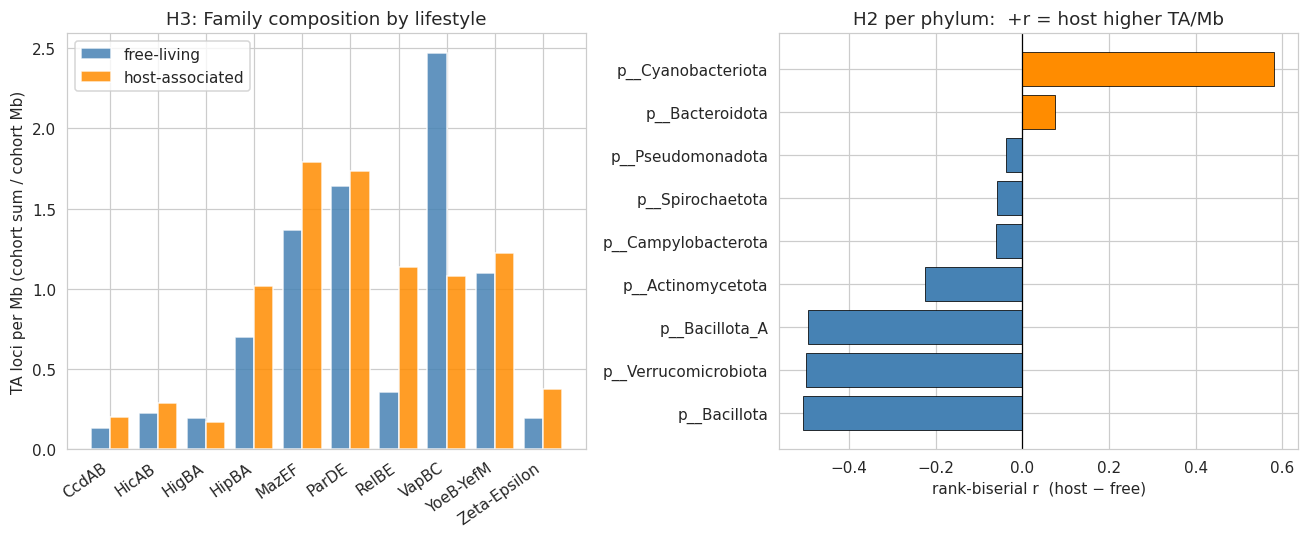

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: family composition, stacked bars of median per-Mb rate by lifestyle
ax = axes[0]
med_host_per_mb = [host[fam].sum() / host['median_size_mb'].sum() for fam in FAMILIES]
med_free_per_mb = [free[fam].sum() / free['median_size_mb'].sum() for fam in FAMILIES]
x = np.arange(len(FAMILIES))
w = 0.4
ax.bar(x - w/2, med_free_per_mb, w, label='free-living', alpha=0.85, color='steelblue')
ax.bar(x + w/2, med_host_per_mb, w, label='host-associated', alpha=0.85, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(FAMILIES, rotation=35, ha='right')
ax.set_ylabel('TA loci per Mb (cohort sum / cohort Mb)')
ax.set_title('H3: Family composition by lifestyle')
ax.legend()

# Panel B: H2 direction by phylum
ax = axes[1]
sig_df = phylum_df.dropna(subset=['H2_r_rb']).sort_values('H2_r_rb')
colors = ['darkorange' if r > 0 else 'steelblue' for r in sig_df['H2_r_rb']]
ax.barh(sig_df['phylum'], sig_df['H2_r_rb'], color=colors, edgecolor='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('rank-biserial r  (host − free)')
ax.set_title('H2 per phylum:  +r = host higher TA/Mb')

fig.tight_layout()
fig.savefig(FIG / 'nb03_family_and_phylum.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Persist NB03 summary


In [10]:
summary = {
    'n_species_cohort': int(len(merged)),
    'families_tested': FAMILIES,
    'H3_family_entropy_host_median': float(host['family_entropy'].median()),
    'H3_family_entropy_free_median': float(free['family_entropy'].median()),
    'H3b_families_bh_significant': int(fs_df['sig_bh_005'].sum()),
    'H1_phylum_preserved_of_10': int((phylum_df['H1_direction'] == '+').sum()),
    'H2_phylum_host_higher_of_testable': int((phylum_df['H2_direction'] == '+').sum()),
    'H2_phylum_testable': int((phylum_df['H2_direction'].isin(['+','-'])).sum()),
}
(DATA / 'nb03_summary.json').write_text(json.dumps(summary, indent=2))
summary


{'n_species_cohort': 2403,
 'families_tested': ['CcdAB',
  'HicAB',
  'HigBA',
  'HipBA',
  'MazEF',
  'ParDE',
  'RelBE',
  'VapBC',
  'YoeB-YefM',
  'Zeta-Epsilon'],
 'H3_family_entropy_host_median': 1.5519014979437444,
 'H3_family_entropy_free_median': 1.5047882836811908,
 'H3b_families_bh_significant': 10,
 'H1_phylum_preserved_of_10': 10,
 'H2_phylum_host_higher_of_testable': 7,
 'H2_phylum_testable': 9}